In [9]:
from pathlib import Path
import json

In [10]:
data_path = Path('data')
assembly_folders = [folder for folder in data_path.iterdir() if folder.is_dir()]
len(assembly_folders), assembly_folders[7]

(751, PosixPath('data/22832_731d3b9f'))

In [11]:
assembly_jsons = []
for folder in assembly_folders:
    with open(folder / 'assembly.json', 'r') as f:
        assembly_jsons.append(json.load(f))

In [12]:
n = len(assembly_jsons)
n

751

проверим пуст ли root?

In [13]:
assembly_jsons[10]['root']

{'component': 'f70a410b-05b5-11ec-993e-0ace72c19443'}

In [14]:
m = 0
for i in range(n):
    if len(assembly_jsons[i]['root']) == 0:
        m += 1
m

0

проверим в каждом ли root есть компанента из components

In [17]:
root_component = assembly_jsons[10]['root']['component']
assembly_jsons[10]['components'][root_component]

{'name': 'root', 'type': 'Component', 'part_number': 'Untitled'}

In [18]:
m = 0
for i in range(n):
    root_component = assembly_jsons[i]['root']['component']
    if root_component not in assembly_jsons[i]['components']:
        m += 1
m

0

проверим что вообще есть в root на первом уровне

In [19]:
content = {}
for i in range(n):
    for key in assembly_jsons[i]['root'].keys():
        if key not in content:
            content[key] = 1
content

{'component': 1, 'bodies': 1}

проверим соответствуют ли root.bodies root_component.bodies 

In [22]:
assembly_jsons[1]['root']['bodies']

{'5a6be276-056e-11ec-a6f3-0226f5980261': {'is_visible': True},
 '5a6c7ebe-056e-11ec-9052-0226f5980261': {'is_visible': True},
 '5a6ccce6-056e-11ec-95d8-0226f5980261': {'is_visible': True},
 '5a6d1ad8-056e-11ec-b01e-0226f5980261': {'is_visible': True},
 '5a6d4200-056e-11ec-9ecd-0226f5980261': {'is_visible': True},
 '5a6d9028-056e-11ec-99b4-0226f5980261': {'is_visible': True},
 '5a6dde0a-056e-11ec-9c1a-0226f5980261': {'is_visible': True},
 '5a6e051c-056e-11ec-ac7a-0226f5980261': {'is_visible': True},
 '5a6e7a52-056e-11ec-a349-0226f5980261': {'is_visible': True},
 '5a6ea186-056e-11ec-94a0-0226f5980261': {'is_visible': True},
 '5a6eef68-056e-11ec-826a-0226f5980261': {'is_visible': True},
 '5a6f3d9c-056e-11ec-b8ff-0226f5980261': {'is_visible': True},
 '5a6f8bb8-056e-11ec-9180-0226f5980261': {'is_visible': True},
 '5a6fd9d8-056e-11ec-97f4-0226f5980261': {'is_visible': True}}

In [23]:
root_component = assembly_jsons[1]['root']['component']
assembly_jsons[1]['components'][root_component]['bodies']

['5a6be276-056e-11ec-a6f3-0226f5980261',
 '5a6c7ebe-056e-11ec-9052-0226f5980261',
 '5a6ccce6-056e-11ec-95d8-0226f5980261',
 '5a6d1ad8-056e-11ec-b01e-0226f5980261',
 '5a6d4200-056e-11ec-9ecd-0226f5980261',
 '5a6d9028-056e-11ec-99b4-0226f5980261',
 '5a6dde0a-056e-11ec-9c1a-0226f5980261',
 '5a6e051c-056e-11ec-ac7a-0226f5980261',
 '5a6e7a52-056e-11ec-a349-0226f5980261',
 '5a6ea186-056e-11ec-94a0-0226f5980261',
 '5a6eef68-056e-11ec-826a-0226f5980261',
 '5a6f3d9c-056e-11ec-b8ff-0226f5980261',
 '5a6f8bb8-056e-11ec-9180-0226f5980261',
 '5a6fd9d8-056e-11ec-97f4-0226f5980261']

In [30]:
m = 0
for i in range(n):
    root_component = assembly_jsons[i]['root']['component']
    root_component_bodies = assembly_jsons[i]['components'][root_component].get('bodies', [])
    root_bodies = assembly_jsons[i]['root'].get('bodies', {})
    if len(root_bodies) != len(root_component_bodies):
        m += 1
        continue
    for bodie in root_component_bodies:
        if bodie not in root_bodies:
            m += 1
            break
    
m

0

посмотрим у скольких объектах пустой tree

In [32]:
m = 0
for i in range(n):
    if len(assembly_jsons[i]['tree']) == 0:
        m += 1

m

0

In [34]:
content = {}
for i in range(n):
    for key in assembly_jsons[i]['tree'].keys():
        if key not in content:
            content[key] = 1 
content

{'root': 1}

In [46]:
m = 0
for i in range(n):
    if len(assembly_jsons[i]['tree']['root']) == 0:
        m += 1
m

343

посмотрим распределение глубины дерева

In [47]:
content = {}
for i in range(n):
    level = [assembly_jsons[i]['tree']['root']]
    j = 0
    m = len(level[0])
    while m > 0:
        new_level = []
        m = 0
        for occ in level:
            for next_occ in occ.keys():
                new_level.append(occ[next_occ])
                m += len(occ[next_occ])
        j += 1
        level = new_level[:]
    if j not in content:
        content[j] = 1
    else:
        content[j] += 1
content

{1: 276, 0: 343, 3: 34, 2: 88, 4: 7, 5: 2, 6: 1}

Все ли occurrences совпадают c tree.root?

In [59]:
k = 0
for i in range(n):
    root_occs = {}
    occs = {occ : 1 for occ in assembly_jsons[i]['occurrences']}
    level = [assembly_jsons[i]['tree']['root']]
    m = len(level[0])
    while m > 0:
        new_level = []
        m = 0
        for occ in level:
            for next_occ in occ.keys():
                new_level.append(occ[next_occ])
                if next_occ not in root_occs:
                    root_occs[next_occ] = 1
                else:
                    root_occs[next_occ] += 1
                m += len(occ[next_occ])
        level = new_level[:]
    if root_occs != occs:
        k += 1
k

0

проверяем length в occurrences transform

In [68]:
occs = assembly_jsons[3]['occurrences'].keys()
for occ in assembly_jsons[3]['occurrences'].keys():
    transform = assembly_jsons[3]['occurrences'][occ]['transform']
    print(transform['x_axis']['length'])
    print(transform['y_axis']['length'])
    print(transform['z_axis']['length'])

1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
0.9999999999999957
0.9999999999999957
1.0
1.0
1.0
1.0
1.0
1.0
1.0
0.9999999999999947
1.0
0.9999999999999947
0.9999999999999999
0.9999999999999999
1.0
1.0000000000000009
1.0000000000000009
1.0
0.9999999999999999
0.9999999999999999
1.0
0.9999999999999906
0.9999999999999908
0.9999999999999999
0.9999999999999941
0.9999999999999941
1.0
0.9999999999999899
0.9999999999999909
0.9999999999999992
0.9999999999999899
0.9999999999999907
0.9999999999999993
0.9999999999999899
0.9999999999999907
0.9999999999999993
1.0000000000000009
1.0000000000000009
1.0
0.9999999999999999
0.9999999999999999
1.0
0.9999999999999906
0.9999999999999908
0.9999999999999999
0.9999999999999941
0.9999999999999941
1.0
0.9999999999999899
0.9999999999999907
0.9999999999999993
0.9999999999999899
0.9999999999999907
0.9999999999999993
0.9999999999999899
0.9999999999

In [79]:
content = {}
for i in range(n):
    for occ in assembly_jsons[i]['occurrences'].keys():
        transform = assembly_jsons[i]['occurrences'][occ]['transform']
        for length in (transform['x_axis']['length'], transform['y_axis']['length'], transform['z_axis']['length']):
            if length not in content:
                content[length] = 1
            else:
                content[length] += 1
import numpy as np
lengths = np.array(list(content.keys()))
lengths[~np.isclose(lengths, 1.0, atol=1e-12)]

array([2.54, 2.54, 2.54])

In [80]:
for i in range(n):
    for occ in assembly_jsons[i]['occurrences'].keys():
        transform = assembly_jsons[i]['occurrences'][occ]['transform']
        for length in (transform['x_axis']['length'], transform['y_axis']['length'], transform['z_axis']['length']):
            if not np.isclose(length, 1.0): 
                print(i)

421
421
421
421
421
421


In [81]:
assembly_folders[421]

PosixPath('data/21722_68aeba65')

In [82]:
i = 421
for occ in assembly_jsons[i]['occurrences'].keys():
    transform = assembly_jsons[i]['occurrences'][occ]['transform']
    for length in (transform['x_axis']['length'], transform['y_axis']['length'], transform['z_axis']['length']):
        if not np.isclose(length, 1.0): 
            print(occ)

f2b28a40-0559-11ec-91ed-06214ff114d7
f2b28a40-0559-11ec-91ed-06214ff114d7
f2b28a40-0559-11ec-91ed-06214ff114d7
f2cc53ca-0559-11ec-95a5-06214ff114d7
f2cc53ca-0559-11ec-95a5-06214ff114d7
f2cc53ca-0559-11ec-95a5-06214ff114d7


In [75]:
lengths = np.array(list(content.keys()))
lengths[~np.isclose(lengths, 1.0, atol=1e-12)]

array([2.54, 2.54, 2.54])

появляется ли root_component в occurrences??

In [92]:
m = 0
for i in range(n):
    root_bodies = assembly_jsons[i]['root'].get('bodies', {})
    tree_root = assembly_jsons[i]['tree']['root']
    if len(root_bodies) != 0 and len(tree_root) != 0:
        print(i)
        m += 1
m

5
7
16
17
19
24
29
30
33
37
41
42
46
47
48
50
54
55
61
62
63
64
65
66
68
70
72
79
80
81
83
84
86
93
102
103
104
108
111
118
119
121
126
127
128
138
143
150
158
160
173
177
192
199
200
201
204
205
209
210
211
213
216
222
224
225
227
232
238
240
245
254
255
258
260
264
265
270
275
278
281
284
285
316
320
324
327
328
336
340
341
343
353
358
359
367
369
372
388
396
401
405
414
415
417
422
423
424
426
432
438
443
451
457
461
463
466
467
470
471
475
479
486
489
494
495
500
502
508
509
513
516
522
524
527
529
530
535
537
540
546
549
554
555
569
570
572
574
578
579
580
594
597
600
602
609
610
624
639
647
649
651
660
662
666
671
679
692
693
697
707
713
717
720
726
730
737
749


178

In [96]:
assembly_folders[5]

PosixPath('data/22680_1f4026f6')

In [93]:
assembly_jsons[5]['tree']

{'root': {'a23d48d2-0601-11ec-9654-02631ee0d5cb': {'a23d96f4-0601-11ec-ac50-02631ee0d5cb': {}}}}

In [94]:
assembly_jsons[5]['root']

{'component': 'a23c858a-0601-11ec-8753-02631ee0d5cb',
 'bodies': {'a23707ec-0601-11ec-99a7-02631ee0d5cb': {'is_visible': True},
  'a2375624-0601-11ec-a69e-02631ee0d5cb': {'is_visible': True},
  'a2377d5c-0601-11ec-b37f-02631ee0d5cb': {'is_visible': True},
  'a237f1ae-0601-11ec-b2ab-02631ee0d5cb': {'is_visible': True},
  'a2384010-0601-11ec-9088-02631ee0d5cb': {'is_visible': True},
  'a238670a-0601-11ec-aa8c-02631ee0d5cb': {'is_visible': True},
  'a238b50a-0601-11ec-99c0-02631ee0d5cb': {'is_visible': True},
  'a239784a-0601-11ec-a895-02631ee0d5cb': {'is_visible': True},
  'a23a1498-0601-11ec-bcb9-02631ee0d5cb': {'is_visible': True},
  'a23ad7e8-0601-11ec-867b-02631ee0d5cb': {'is_visible': True},
  'a23b9b4c-0601-11ec-a3ef-02631ee0d5cb': {'is_visible': True}}}

попробуем отрисовать картинки для сложного json

In [107]:
from pytorch3d.io import load_objs_as_meshes
assmbl_path = 'data/20818_098cad7c'
assmbl = load_objs_as_meshes([assmbl_path + '/assembly.obj'])

# Vertices: 12023
# Triangles : 12278

In [110]:
assmbl.verts_list()[0].shape, assmbl.verts_normals_list()[0].shape, assmbl.faces_list()[0].shape

(torch.Size([12023, 3]), torch.Size([12023, 3]), torch.Size([12278, 3]))

In [120]:
import torch
verts = assmbl.verts_list()[0]
center = torch.mean(verts, dim=0)
radius = torch.norm(verts - center, dim=1).max()
center, radius

(tensor([-5.2096,  1.9290,  5.9191]), tensor(14.0683))

In [122]:
torch.rand(1).item()

0.9402647614479065

In [139]:
elev = 90 - torch.rand(1).item() * 180 
azim = torch.rand(1).item() * 360
dist = radius * (0.3 + torch.rand(1).item() * 1.7)

In [140]:
from pytorch3d.renderer.cameras import look_at_view_transform, FoVPerspectiveCameras
R, T = look_at_view_transform(dist, elev, azim)
camera = FoVPerspectiveCameras(fov=60, R = R, T = T)
camera

FoVPerspectiveCameras()

In [141]:
from pytorch3d.renderer import MeshRasterizer, RasterizationSettings
renderer = MeshRasterizer(cameras=camera, raster_settings=RasterizationSettings(256, faces_per_pixel=1))
renderer

MeshRasterizer(
  (cameras): FoVPerspectiveCameras()
)

In [142]:
fragments = renderer(assmbl)

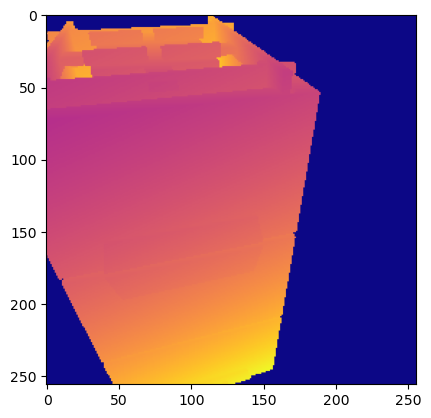

In [143]:
import matplotlib.pyplot as plt
depths = fragments.zbuf[0, ..., 0]
plt.imshow(depths.cpu().numpy(), cmap='plasma')
plt.show()

In [144]:
with open(assmbl_path + '/assembly.json', 'r') as f:
    assmbl_json = json.load(f)


In [145]:
root_component = assmbl_json['root']['component']
root_component_bodies = [k for k, v in assmbl_json['root']['bodies'].items() if v['is_visible']]
root_component, root_component_bodies

('039ff6cb-0526-11ec-8910-061e4e83ef1b',
 ['0396cf1c-0526-11ec-839a-061e4e83ef1b',
  '0396f648-0526-11ec-99c1-061e4e83ef1b',
  '0397444c-0526-11ec-89f3-061e4e83ef1b',
  '03979276-0526-11ec-a220-061e4e83ef1b',
  '0397e09c-0526-11ec-a283-061e4e83ef1b',
  '039807cc-0526-11ec-8120-061e4e83ef1b',
  '039855be-0526-11ec-8d00-061e4e83ef1b',
  '0398a3de-0526-11ec-b7c8-061e4e83ef1b',
  '0398f200-0526-11ec-b13c-061e4e83ef1b',
  '03994022-0526-11ec-bbd2-061e4e83ef1b',
  '0399b550-0526-11ec-a011-061e4e83ef1b',
  '039a0376-0526-11ec-b8d6-061e4e83ef1b'])

In [146]:
root_component_mesh = load_objs_as_meshes([assmbl_path + '/' + bodie + '.obj' for bodie in root_component_bodies])

/Users/neonilllai/miniconda3/envs/fusion_env/lib/python3.10/site-packages/pytorch3d/io/obj_io.py:547: UserWarning: No mtl file provided
  warnings.warn("No mtl file provided")


In [147]:
fragments = renderer(root_component_mesh)

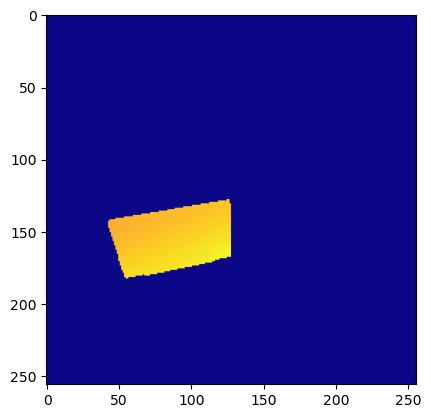

In [148]:
depths = fragments.zbuf[0, ..., 0]
plt.imshow(depths.cpu().numpy(), cmap='plasma')
plt.show()

In [ ]:
for tree

In [ ]:
fragments = renderer(assmbl)

In [53]:
len(occs), len(root_occs)

(104, 6)

In [55]:
m = 0
level = [root_occs]
while len(level) > 0:
    new_level = []
    for occ in level:
        m += len(occ)
        for next_occ in occ.keys():
            if len(occ[next_occ]) > 0:
                new_level.append(occ[next_occ])
    level = new_level[:]
m

104